In [4]:
#importiamo le librerie di base
import numpy as np 
import pandas as pd 
import librosa.display  
import matplotlib.pyplot as plt  
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PowerTransformer  # Importa PowerTransformer
from sklearn.preprocessing import QuantileTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score, hinge_loss
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.pipeline import make_pipeline
from sklearn.inspection import permutation_importance


In [5]:

pd.set_option('display.max_columns', None)  #per stampare tutte le colonne
music_data_original = pd.read_csv('Data/features_3_sec.csv') 


colonne=music_data_original.columns.size
print(f'IL DATASET PRESO UN CONSIDERAZIONE HA {colonne} PER OGNI CAMPIONE')
music_data_original.head(5) 


IL DATASET PRESO UN CONSIDERAZIONE HA 60 PER OGNI CAMPIONE


,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,rolloff_mean,rolloff_var,zero_crossing_rate_mean,zero_crossing_rate_var,harmony_mean,harmony_var,perceptr_mean,perceptr_var,tempo,mfcc1_mean,mfcc1_var,mfcc2_mean,mfcc2_var,mfcc3_mean,mfcc3_var,mfcc4_mean,mfcc4_var,mfcc5_mean,mfcc5_var,mfcc6_mean,mfcc6_var,mfcc7_mean,mfcc7_var,mfcc8_mean,mfcc8_var,mfcc9_mean,mfcc9_var,mfcc10_mean,mfcc10_var,mfcc11_mean,mfcc11_var,mfcc12_mean,mfcc12_var,mfcc13_mean,mfcc13_var,mfcc14_mean,mfcc14_var,mfcc15_mean,mfcc15_var,mfcc16_mean,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.0.wav,66149,0.335406,0.091048,0.130405,0.003521,1773.065032,167541.630869,1972.744388,117335.771563,3714.560359,1.080790e+06,0.081851,0.000558,-0.000078,0.008354,-0.000068,0.005535,129.199219,-118.627914,2440.286621,125.083626,260.956909,-23.443724,364.081726,41.321484,181.694855,-5.976108,152.963135,20.115141,75.652298,-16.045410,40.227104,17.855198,84.320282,-14.633434,83.437233,10.270527,97.001335,-9.708279,66.669891,10.183875,45.103611,-4.681614,34.169498,8.417439,48.269444,-7.233477,42.770947,-2.853603,39.687145,-3.241280,36.488243,0.722209,38.099152,-5.050335,33.618073,-0.243027,43.771767,blues
1,blues.00000.1.wav,66149,0.343065,0.086147,0.112699,0.001450,1816.693777,90525.690866,2010.051501,65671.875673,3869.682242,6.722448e+05,0.087173,0.001030,-0.000099,0.004950,-0.000103,0.004854,123.046875,-125.590706,2038.344238,122.421227,216.774185,-20.718019,231.979767,50.128387,142.700409,-11.333302,139.243118,21.385401,77.817947,-15.960796,97.364029,19.454103,57.948093,-12.465918,68.271523,17.898169,56.222176,-11.732554,54.373909,8.145000,40.662876,-7.717751,30.808521,8.397150,48.784225,-8.300493,68.584824,4.074709,64.748276,-6.055294,40.677654,0.159015,51.264091,-2.837699,97.030830,5.784063,59.943081,blues
2,blues.00000.2.wav,66149,0.346815,0.092243,0.132003,0.004620,1788.539719,111407.437613,2084.565132,75124.921716,3997.639160,7.907127e+05,0.071383,0.000425,-0.000066,0.012476,0.000065,0.004357,123.046875,-132.441940,3798.532227,115.085175,257.321289,-14.811666,192.448074,50.189293,144.166031,-0.680819,128.376892,24.650375,66.371170,-13.506104,89.319336,15.643386,55.253967,-13.216637,120.308784,10.406025,35.757862,-7.991465,47.911613,11.853963,36.569931,-4.677677,40.725075,6.571110,30.686846,-2.424750,50.313499,4.806280,67.336563,-1.768610,28.348579,2.378768,45.717648,-1.938424,53.050835,2.517375,33.105122,blues
3,blues.00000.3.wav,66149,0.363639,0.086856,0.132565,0.002448,1655.289045,111952.284517,1960.039988,82913.639269,3568.300218,9.216524e+05,0.069426,0.000304,-0.000014,0.008318,0.000018,0.005927,123.046875,-118.231087,2508.781006,132.116501,332.650574,-18.758335,109.357529,39.769306,184.693344,-13.260426,144.398224,20.468134,122.516464,-14.563448,68.937332,18.745104,74.748886,-13.755463,73.868576,12.993759,41.549564,-12.648887,58.540478,10.389314,39.102024,-4.362739,60.714748,9.156193,40.411537,-9.889441,44.666325,-1.359111,47.739452,-3.841155,28.337118,1.218588,34.770935,-3.580352,50.836224,3.630866,32.023678,blues
4,blues.00000.4.wav,66149,0.335579,0.088129,0.143289,0.001701,1630.656199,79667.267654,1948.503884,60204.020268,3469.992864,6.102111e+05,0.070095,0.000289,0.000041,0.009634,-0.000106,0.005833,123.046875,-105.968376,2118.919922,134.643646,219.562622,-19.961748,171.878754,40.171753,103.120712,-14.271939,102.651230,18.734617,79.070000,-15.619381,48.510284,19.207966,53.642956,-18.274683,95.300995,14.316693,58.821163,-5.792194,55.030254,17.045437,43.229939,-5.681399,46.515259,5.705521,24.956211,-7.986080,39.816933,2.092937,30.336359,0.664582,45.880913,1.689446,51.363583,-3.392489,26.738789,0.536961,29.146694,blues


<h1 STUDIO DELLA VARIANZA SPIEGATA>

STUDIO VARIANZA SPIEGATA

In [6]:
# Rimuovi le colonne non numeriche
X = music_data_original.drop(columns=['label', 'filename'])
feature_names = X.columns  # Salva i nomi delle colonne originali

# Normalizza i dati
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Applica PCA
pca = PCA()  # Per calcolare tutte le componenti principali
X_pca = pca.fit_transform(X_scaled)

# Identifica le feature più rappresentative per ogni componente principale
pc_feature_contributions = pd.DataFrame(pca.components_, columns=feature_names, index=[f'PC{i+1}' for i in range(len(pca.components_))])

# Trova la feature con il valore assoluto più alto per ogni PC
most_influential_features = pc_feature_contributions.abs().idxmax(axis=1)
explained_variances = pca.explained_variance_ratio_

# Combina i risultati in un DataFrame
pc_summary = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(len(pca.components_))],
    'Most Influential Feature': most_influential_features.values,
    'Explained Variance Ratio': explained_variances
})

print(pc_summary)

# HO 58 COMPONENTI PERCHE' NE SONO STATE TOLTE 2: FILE NAME E LABEL 

   Principal Component Most Influential Feature  Explained Variance Ratio
0                  PC1    spectral_centroid_var                  0.200550
1                  PC2               mfcc1_mean                  0.135427
2                  PC3              mfcc10_mean                  0.103453
3                  PC4               mfcc19_var                  0.065943
4                  PC5              mfcc16_mean                  0.043561
5                  PC6              harmony_var                  0.036772
6                  PC7               mfcc18_var                  0.029538
7                  PC8            perceptr_mean                  0.026538
8                  PC9             harmony_mean                  0.024887
9                 PC10              mfcc20_mean                  0.021422
10                PC11                    tempo                  0.018583
11                PC12                    tempo                  0.017399
12                PC13                

<h1 STUDIO DELLE FEATURE DI 3 SECONDI>

GRAFICO DELLA VRIANZA SPIEGATA

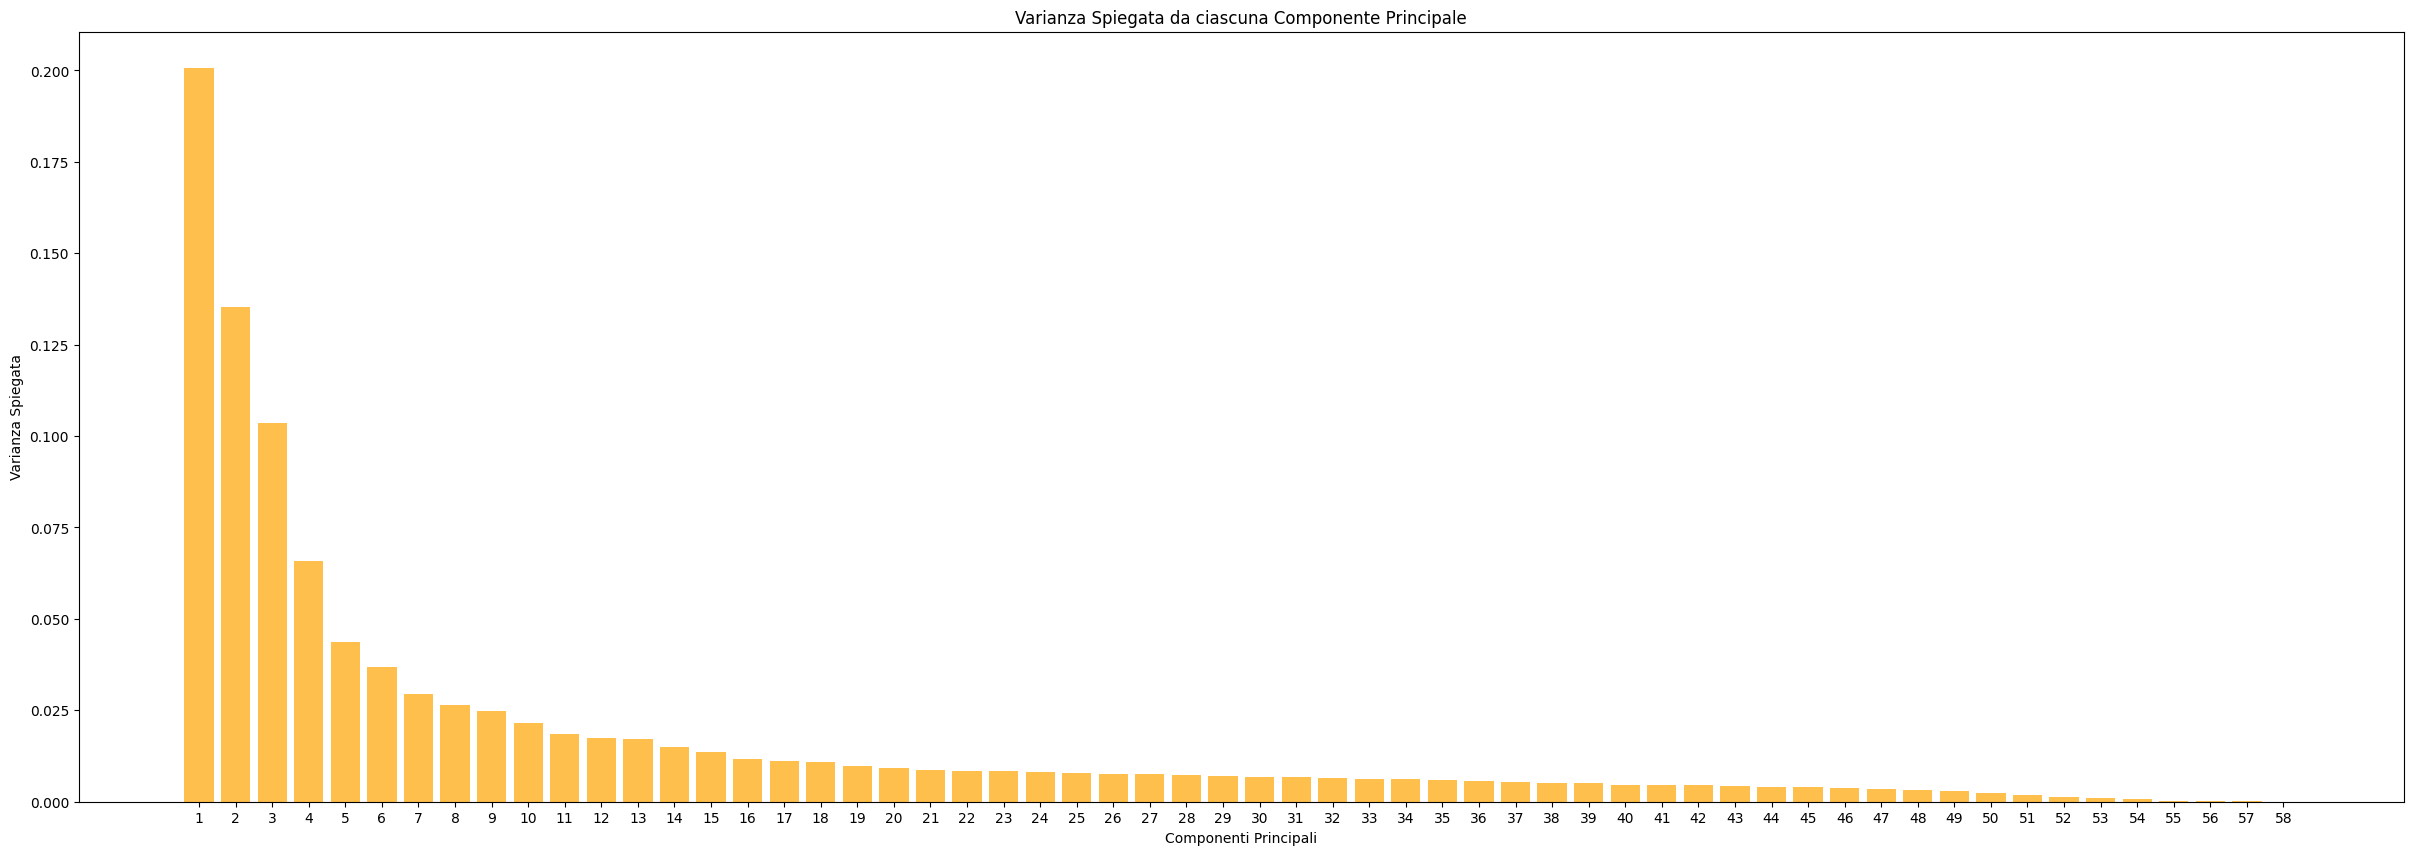

In [7]:
# Grafico della varianza spiegata da ciascuna componente principale
plt.figure(figsize=(30, 10))
plt.bar(range(1, len(explained_variances) + 1), explained_variances, alpha=0.7, color='orange')
plt.xlabel('Componenti Principali')
plt.ylabel('Varianza Spiegata')
plt.title('Varianza Spiegata da ciascuna Componente Principale')
plt.xticks(range(1, len(explained_variances) + 1))  # Aggiungi i numeri delle componenti sull'asse x
plt.show()

CERCO DI ESTRARRE QUALCHE ALTRA FEATURE DAL DATASET PER VEDERE SE SI MIGLIORANO I RISULTATI

In [8]:
# Passo 2: Aggiungi le nuove colonne

music_data_mod = pd.read_csv('Data/features_3_sec.csv') 

music_data_mod['rms_var_to_mean'] = music_data_mod['rms_var'] / music_data_mod['rms_mean']
music_data_mod['chroma_stft_var_to_mean'] = music_data_mod['chroma_stft_var'] / music_data_mod['chroma_stft_mean']
music_data_mod['rolloff_to_centroid'] = music_data_mod['rolloff_mean'] / music_data_mod['spectral_centroid_mean']
music_data_mod['spectral_bandwidth_to_centroid'] = music_data_mod['spectral_bandwidth_mean'] / music_data_mod['spectral_centroid_mean']
music_data_mod['mfcc_mean_sum'] = music_data_mod[[f'mfcc{i}_mean' for i in range(1, 21)]].sum(axis=1)
music_data_mod['mfcc_var_sum'] = music_data_mod[[f'mfcc{i}_var' for i in range(1, 21)]].sum(axis=1)
music_data_mod['tempo_normalized'] = music_data_mod['tempo'] / music_data_mod['length']
music_data_mod['zero_cross_rolloff_ratio'] = music_data_mod['zero_crossing_rate_mean'] / music_data_mod['rolloff_mean']

colonne=music_data_mod.columns.size
print(colonne)

# Rimuovi le colonne non numeriche
X = music_data_mod.drop(columns=['label', 'filename'])
feature_names = X.columns  # Salva i nomi delle colonne originali

# Normalizza i dati
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Applica PCA
pca = PCA()  # Per calcolare tutte le componenti principali
X_pca = pca.fit_transform(X_scaled)

# Identifica le feature più rappresentative per ogni componente principale
pc_feature_contributions = pd.DataFrame(pca.components_, columns=feature_names, index=[f'PC{i+1}' for i in range(len(pca.components_))])

# Trova la feature con il valore assoluto più alto per ogni PC
most_influential_features = pc_feature_contributions.abs().idxmax(axis=1)
explained_variances = pca.explained_variance_ratio_

# Combina i risultati in un DataFrame
pc_summary = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(len(pca.components_))],
    'Most Influential Feature': most_influential_features.values,
    'Explained Variance Ratio': explained_variances
})
pd.set_option('display.max_columns', None)  #per stampare tutte le colonne
print(pc_summary)


68
   Principal Component  Most Influential Feature  Explained Variance Ratio
0                  PC1     spectral_centroid_var              1.929522e-01
1                  PC2                mfcc1_mean              1.476650e-01
2                  PC3                mfcc7_mean              9.374632e-02
3                  PC4   zero_crossing_rate_mean              6.564880e-02
4                  PC5  zero_cross_rolloff_ratio              4.575987e-02
..                 ...                       ...                       ...
61                PC62    spectral_centroid_mean              1.551341e-05
62                PC63             mfcc_mean_sum              1.198987e-17
63                PC64          tempo_normalized              5.075245e-18
64                PC65              mfcc_var_sum              1.446969e-18
65                PC66                    length              0.000000e+00

[66 rows x 3 columns]


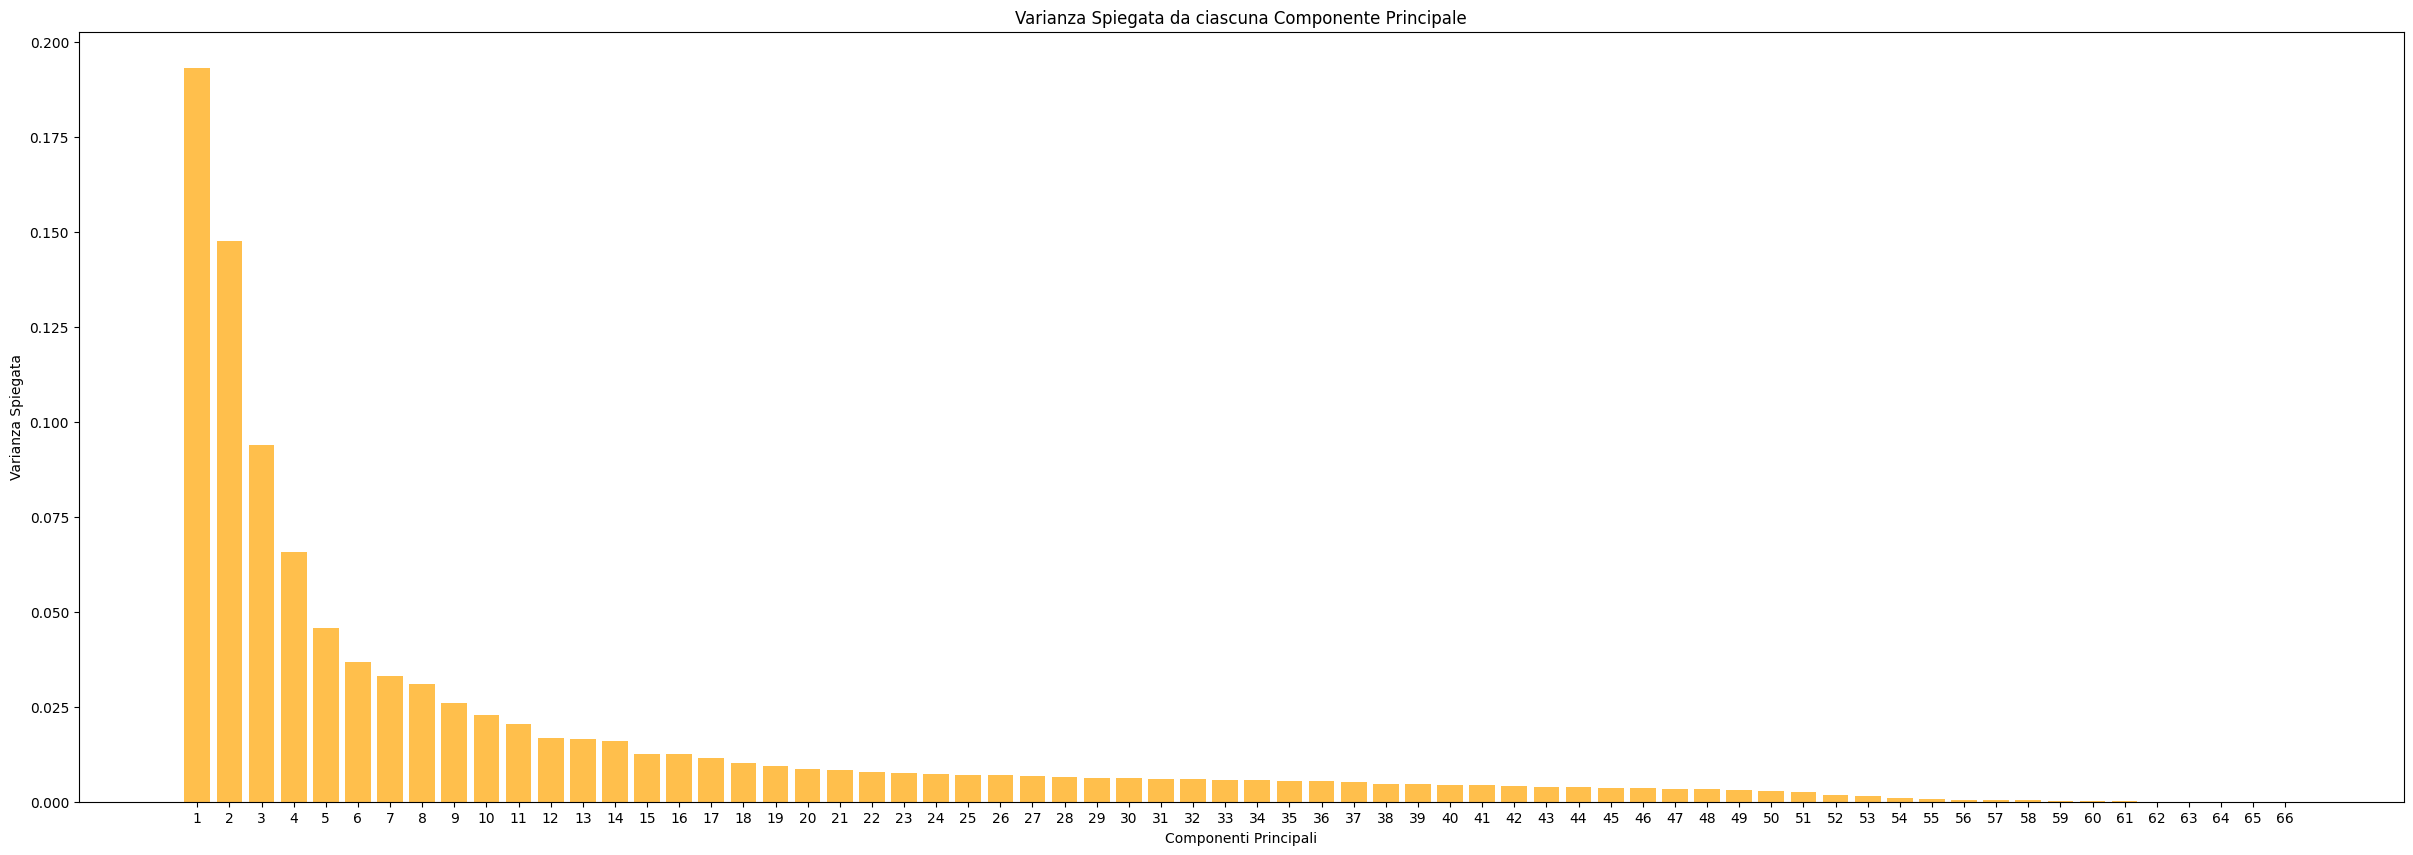

In [9]:
# Grafico della varianza spiegata da ciascuna componente principale
plt.figure(figsize=(30, 10))
plt.bar(range(1, len(explained_variances) + 1), explained_variances, alpha=0.7, color='orange')
plt.xlabel('Componenti Principali')
plt.ylabel('Varianza Spiegata')
plt.title('Varianza Spiegata da ciascuna Componente Principale')
plt.xticks(range(1, len(explained_variances) + 1))  # Aggiungi i numeri delle componenti sull'asse x
plt.show()

In [10]:
# Separare le caratteristiche e le etichette
X = music_data_original.drop(columns=['filename', 'label'])  # Rimuovi filename e label
y = music_data_original['label']  # Etichette

# Suddividere il music_data_originalset in set di addestramento e test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardizzare le caratteristiche
robust = RobustScaler()
standard = StandardScaler()
minmax = MinMaxScaler()
power = PowerTransformer()
scalers=[robust, standard, minmax, power]

for scaler in scalers:
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Creare il modello SVM
    model = SVC(C=10, gamma='scale', kernel='rbf')
    model.fit(X_train, y_train)

    # Prevedere le etichette per il set di test
    y_pred = model.predict(X_test)

    # Calcolare l'accuratezza
    # Calcolare metriche
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro')  # Macro per bilanciare le classi
    recall = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    f2 = fbeta_score(y_test, y_pred, beta=2, average='macro')  # F2-score con beta=2

    # Stampare i risultati
    print(f'           Scaler: {scaler}')
    print(f'Accuratezza: {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1-score: {f1:.4f}')
    print(f'F2-score: {f2:.4f}')
   # print(f'Hinge Loss: {loss}')
    print('------------------------------------------------------------')

           Scaler: RobustScaler()
Accuratezza: 0.8784
Precision: 0.8793
Recall: 0.8780
F1-score: 0.8774
F2-score: 0.8774
------------------------------------------------------------
           Scaler: StandardScaler()
Accuratezza: 0.9314
Precision: 0.9313
Recall: 0.9308
F1-score: 0.9304
F2-score: 0.9305
------------------------------------------------------------
           Scaler: MinMaxScaler()
Accuratezza: 0.8634
Precision: 0.8634
Recall: 0.8634
F1-score: 0.8626
F2-score: 0.8629
------------------------------------------------------------
           Scaler: PowerTransformer()
Accuratezza: 0.9349
Precision: 0.9350
Recall: 0.9343
F1-score: 0.9340
F2-score: 0.9341
------------------------------------------------------------


<h1 STUDIO DELLE FEATURE DI 3S>

In [11]:
# Separare le caratteristiche e le etichette
X = music_data_mod.drop(columns=['filename', 'label'])  # Rimuovi filename e label
y = music_data_mod['label']  # Etichette

# Suddividere il music_data_originalset in set di addestramento e test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardizzare le caratteristiche
robust = RobustScaler()
standard = StandardScaler()
minmax = MinMaxScaler()
power = PowerTransformer()
scalers=[robust, standard, minmax, power]

for scaler in scalers:
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Creare il modello SVM
    model = SVC(C=10, gamma='scale', kernel='rbf')
    model.fit(X_train, y_train)

    # Prevedere le etichette per il set di test
    y_pred = model.predict(X_test)

    # Calcolare l'accuratezza
    # Calcolare metriche
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro')  # Macro per bilanciare le classi
    recall = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    f2 = fbeta_score(y_test, y_pred, beta=2, average='macro')  # F2-score con beta=2

    # Stampare i risultati
    print(f'           Scaler: {scaler}')
    print(f'Accuratezza: {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1-score: {f1:.4f}')
    print(f'F2-score: {f2:.4f}')
   # print(f'Hinge Loss: {loss}')
    print('------------------------------------------------------------')

           Scaler: RobustScaler()
Accuratezza: 0.8889
Precision: 0.8897
Recall: 0.8888
F1-score: 0.8882
F2-score: 0.8883
------------------------------------------------------------
           Scaler: StandardScaler()
Accuratezza: 0.9289
Precision: 0.9284
Recall: 0.9283
F1-score: 0.9279
F2-score: 0.9280
------------------------------------------------------------
           Scaler: MinMaxScaler()
Accuratezza: 0.8609
Precision: 0.8610
Recall: 0.8611
F1-score: 0.8602
F2-score: 0.8606
------------------------------------------------------------
           Scaler: PowerTransformer()
Accuratezza: 0.9309
Precision: 0.9306
Recall: 0.9303
F1-score: 0.9301
F2-score: 0.9302
------------------------------------------------------------


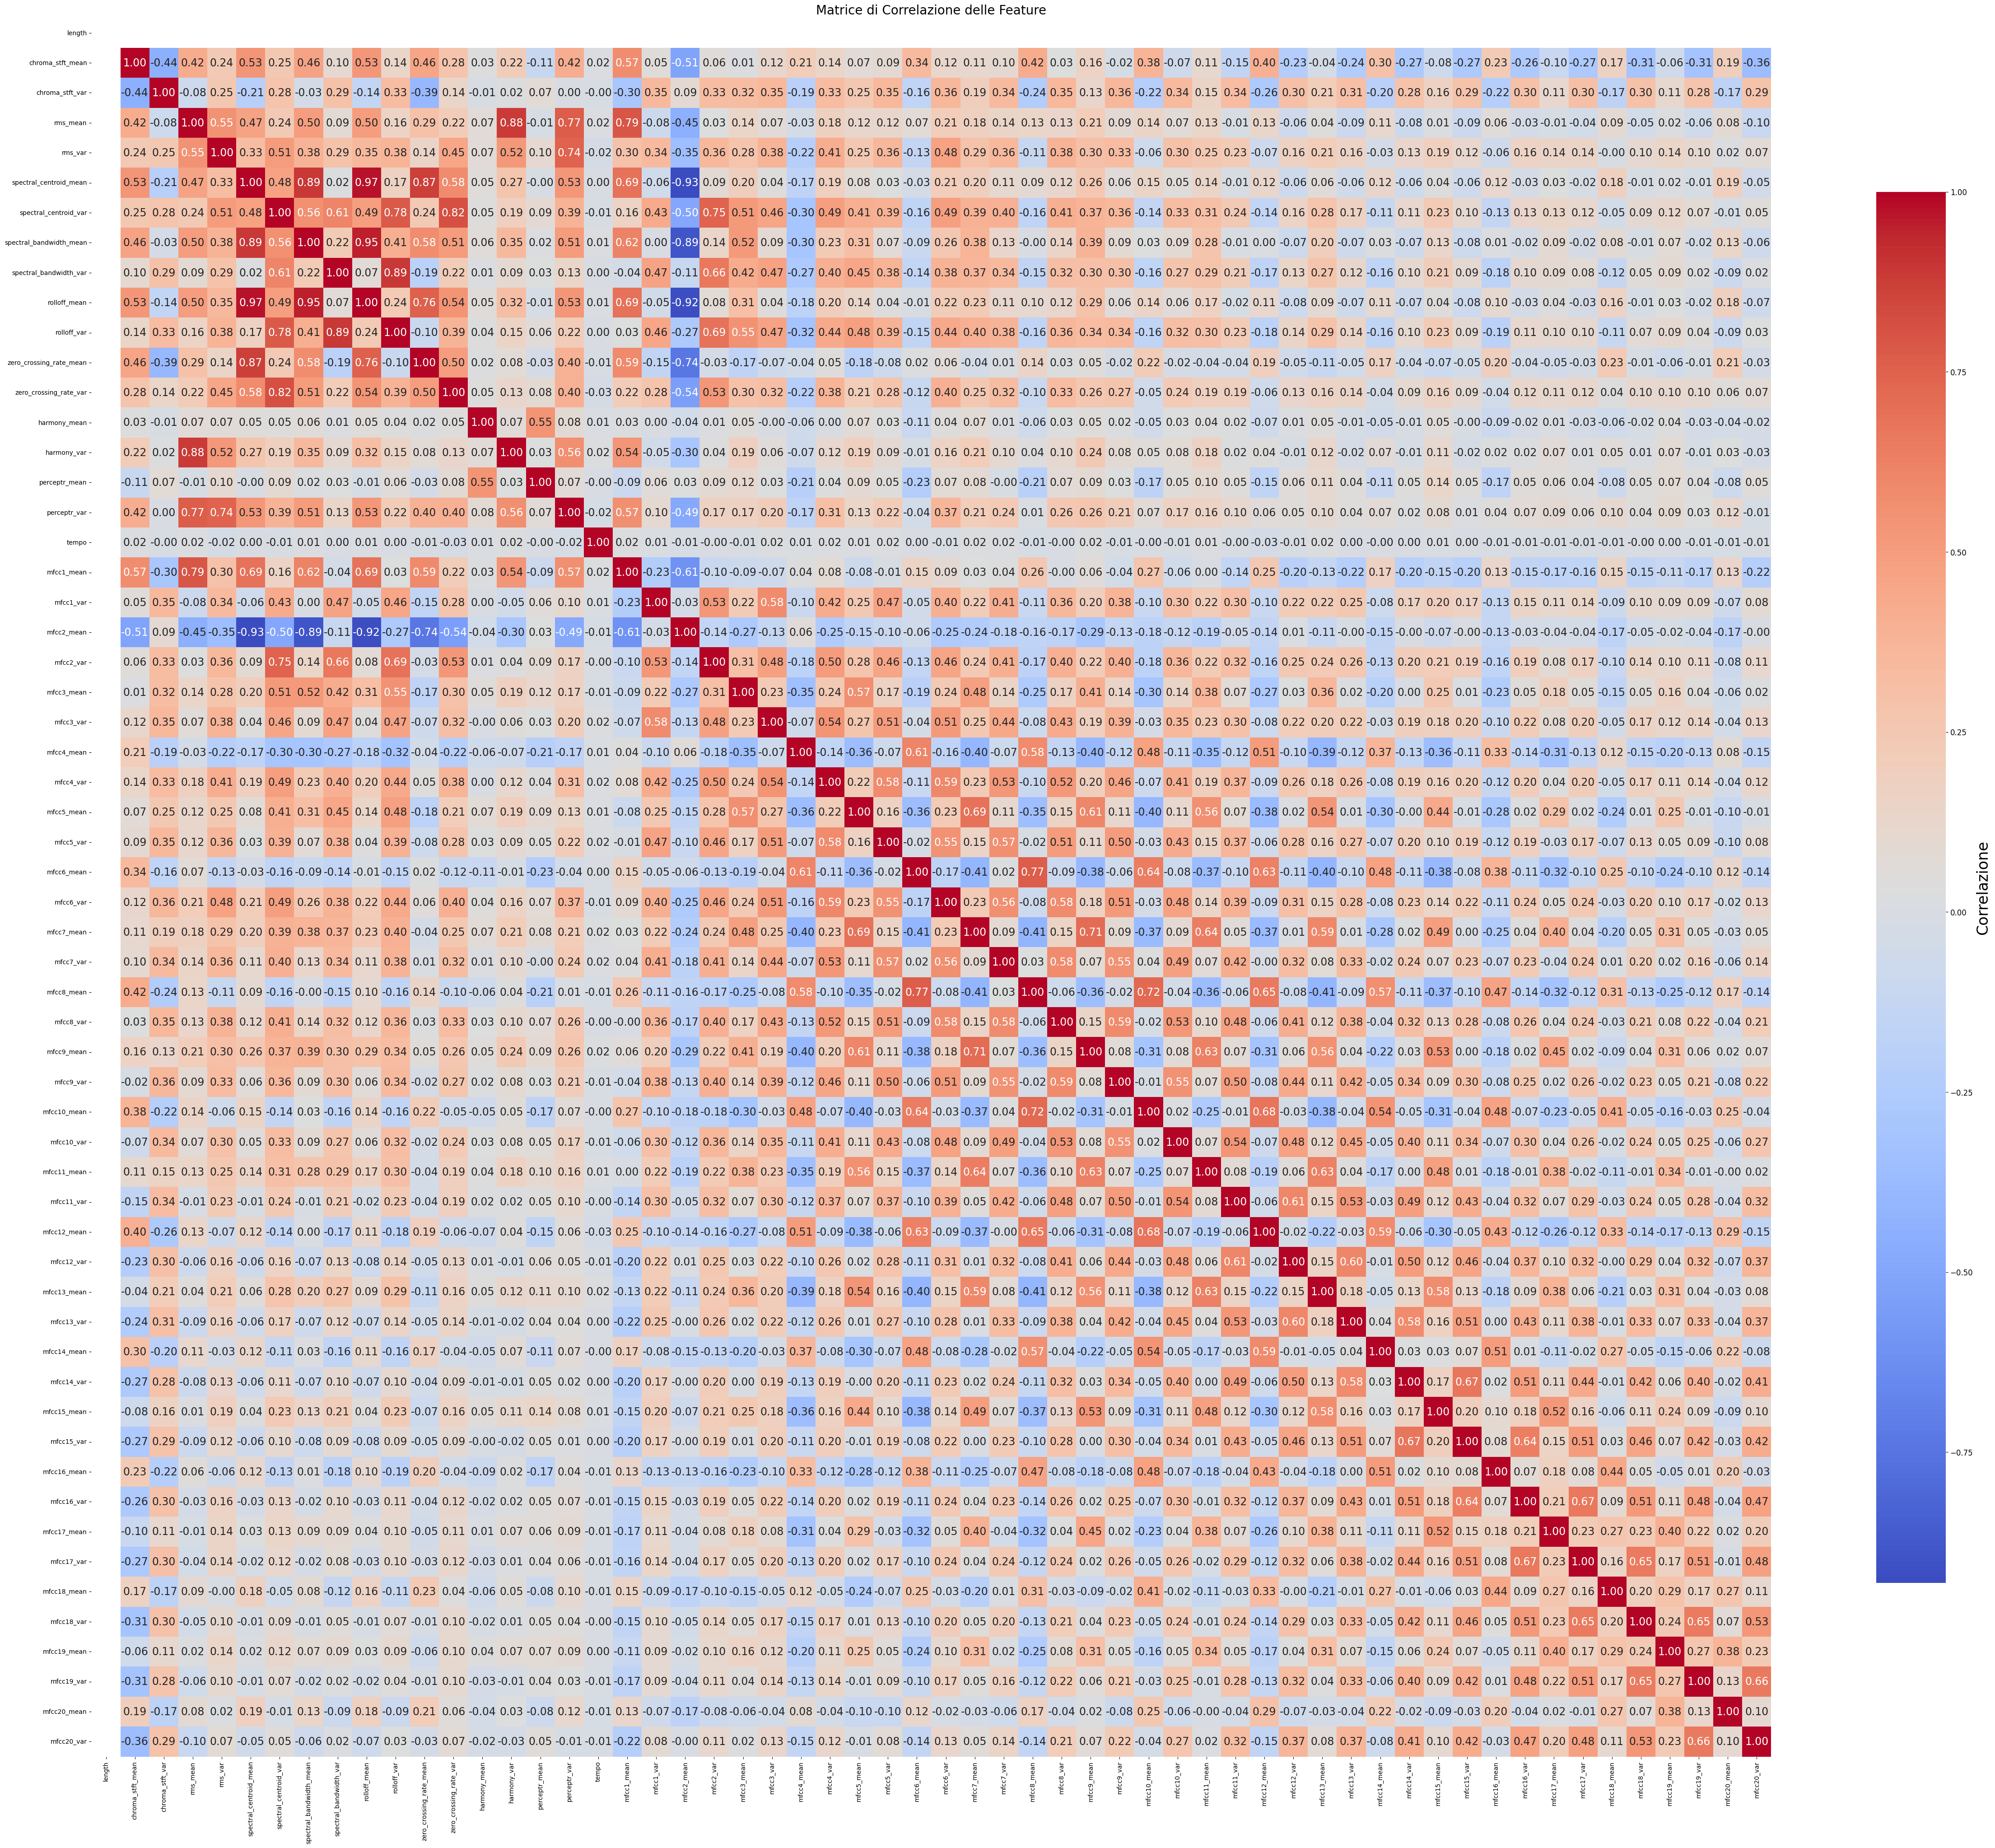

In [12]:
# Rimuovi le colonne non numeriche

X = music_data_original.drop(columns=['label', 'filename'])

# Calcola la matrice di correlazione
correlation_matrix = X.corr()

# Configura la dimensione della heatmap
plt.figure(figsize=(60, 50))

# Crea la heatmap
heatmap = sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm',
                       xticklabels=X.columns, yticklabels=X.columns,
                       annot_kws={"size": 17},  # Aumenta la dimensione del font per i valori
                       cbar_kws={"shrink": 0.8, "label": "Correlazione"})  # Rimuovi fontsize da qui


plt.title('Matrice di Correlazione delle Feature', fontsize=20)  # Aumenta la dimensione del titolo


# Personalizza il colorbar
colorbar = heatmap.collections[0].colorbar  # Ottieni il colorbar dalla heatmap
colorbar.ax.tick_params(labelsize=12)  # Aumenta la dimensione del font dei ticks
colorbar.set_label("Correlazione", fontsize=24)  # Imposta il font della label del colorbar


# Mostra la heatmap

plt.show()

In [13]:
# Separare le caratteristiche e le etichette
X = music_data_original.drop(columns=['filename', 'label','rolloff_mean','mfcc2_mean'])  # Rimuovi filename e label
y = music_data_original['label']  # Etichette

# Suddividere il music_data_originalset in set di addestramento e test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardizzare le caratteristiche
robust = RobustScaler()
standard = StandardScaler()
minmax = MinMaxScaler()
power = PowerTransformer()
scalers=[robust, standard, minmax, power]

for scaler in scalers:
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Creare il modello SVM
    model = SVC(C=10, gamma='scale', kernel='rbf')
    model.fit(X_train, y_train)

    # Prevedere le etichette per il set di test
    y_pred = model.predict(X_test)

    # Calcolare l'accuratezza
    # Calcolare metriche
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro')  # Macro per bilanciare le classi
    recall = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    f2 = fbeta_score(y_test, y_pred, beta=2, average='macro')  # F2-score con beta=2

    # Stampare i risultati
    print(f'           Scaler: {scaler}')
    print(f'Accuratezza: {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1-score: {f1:.4f}')
    print(f'F2-score: {f2:.4f}')
   # print(f'Hinge Loss: {loss}')
    print('------------------------------------------------------------')

           Scaler: RobustScaler()
Accuratezza: 0.8724
Precision: 0.8728
Recall: 0.8720
F1-score: 0.8712
F2-score: 0.8714
------------------------------------------------------------
           Scaler: StandardScaler()
Accuratezza: 0.9269
Precision: 0.9272
Recall: 0.9262
F1-score: 0.9260
F2-score: 0.9260
------------------------------------------------------------
           Scaler: MinMaxScaler()
Accuratezza: 0.8619
Precision: 0.8618
Recall: 0.8621
F1-score: 0.8611
F2-score: 0.8615
------------------------------------------------------------
           Scaler: PowerTransformer()
Accuratezza: 0.9319
Precision: 0.9318
Recall: 0.9313
F1-score: 0.9310
F2-score: 0.9310
------------------------------------------------------------


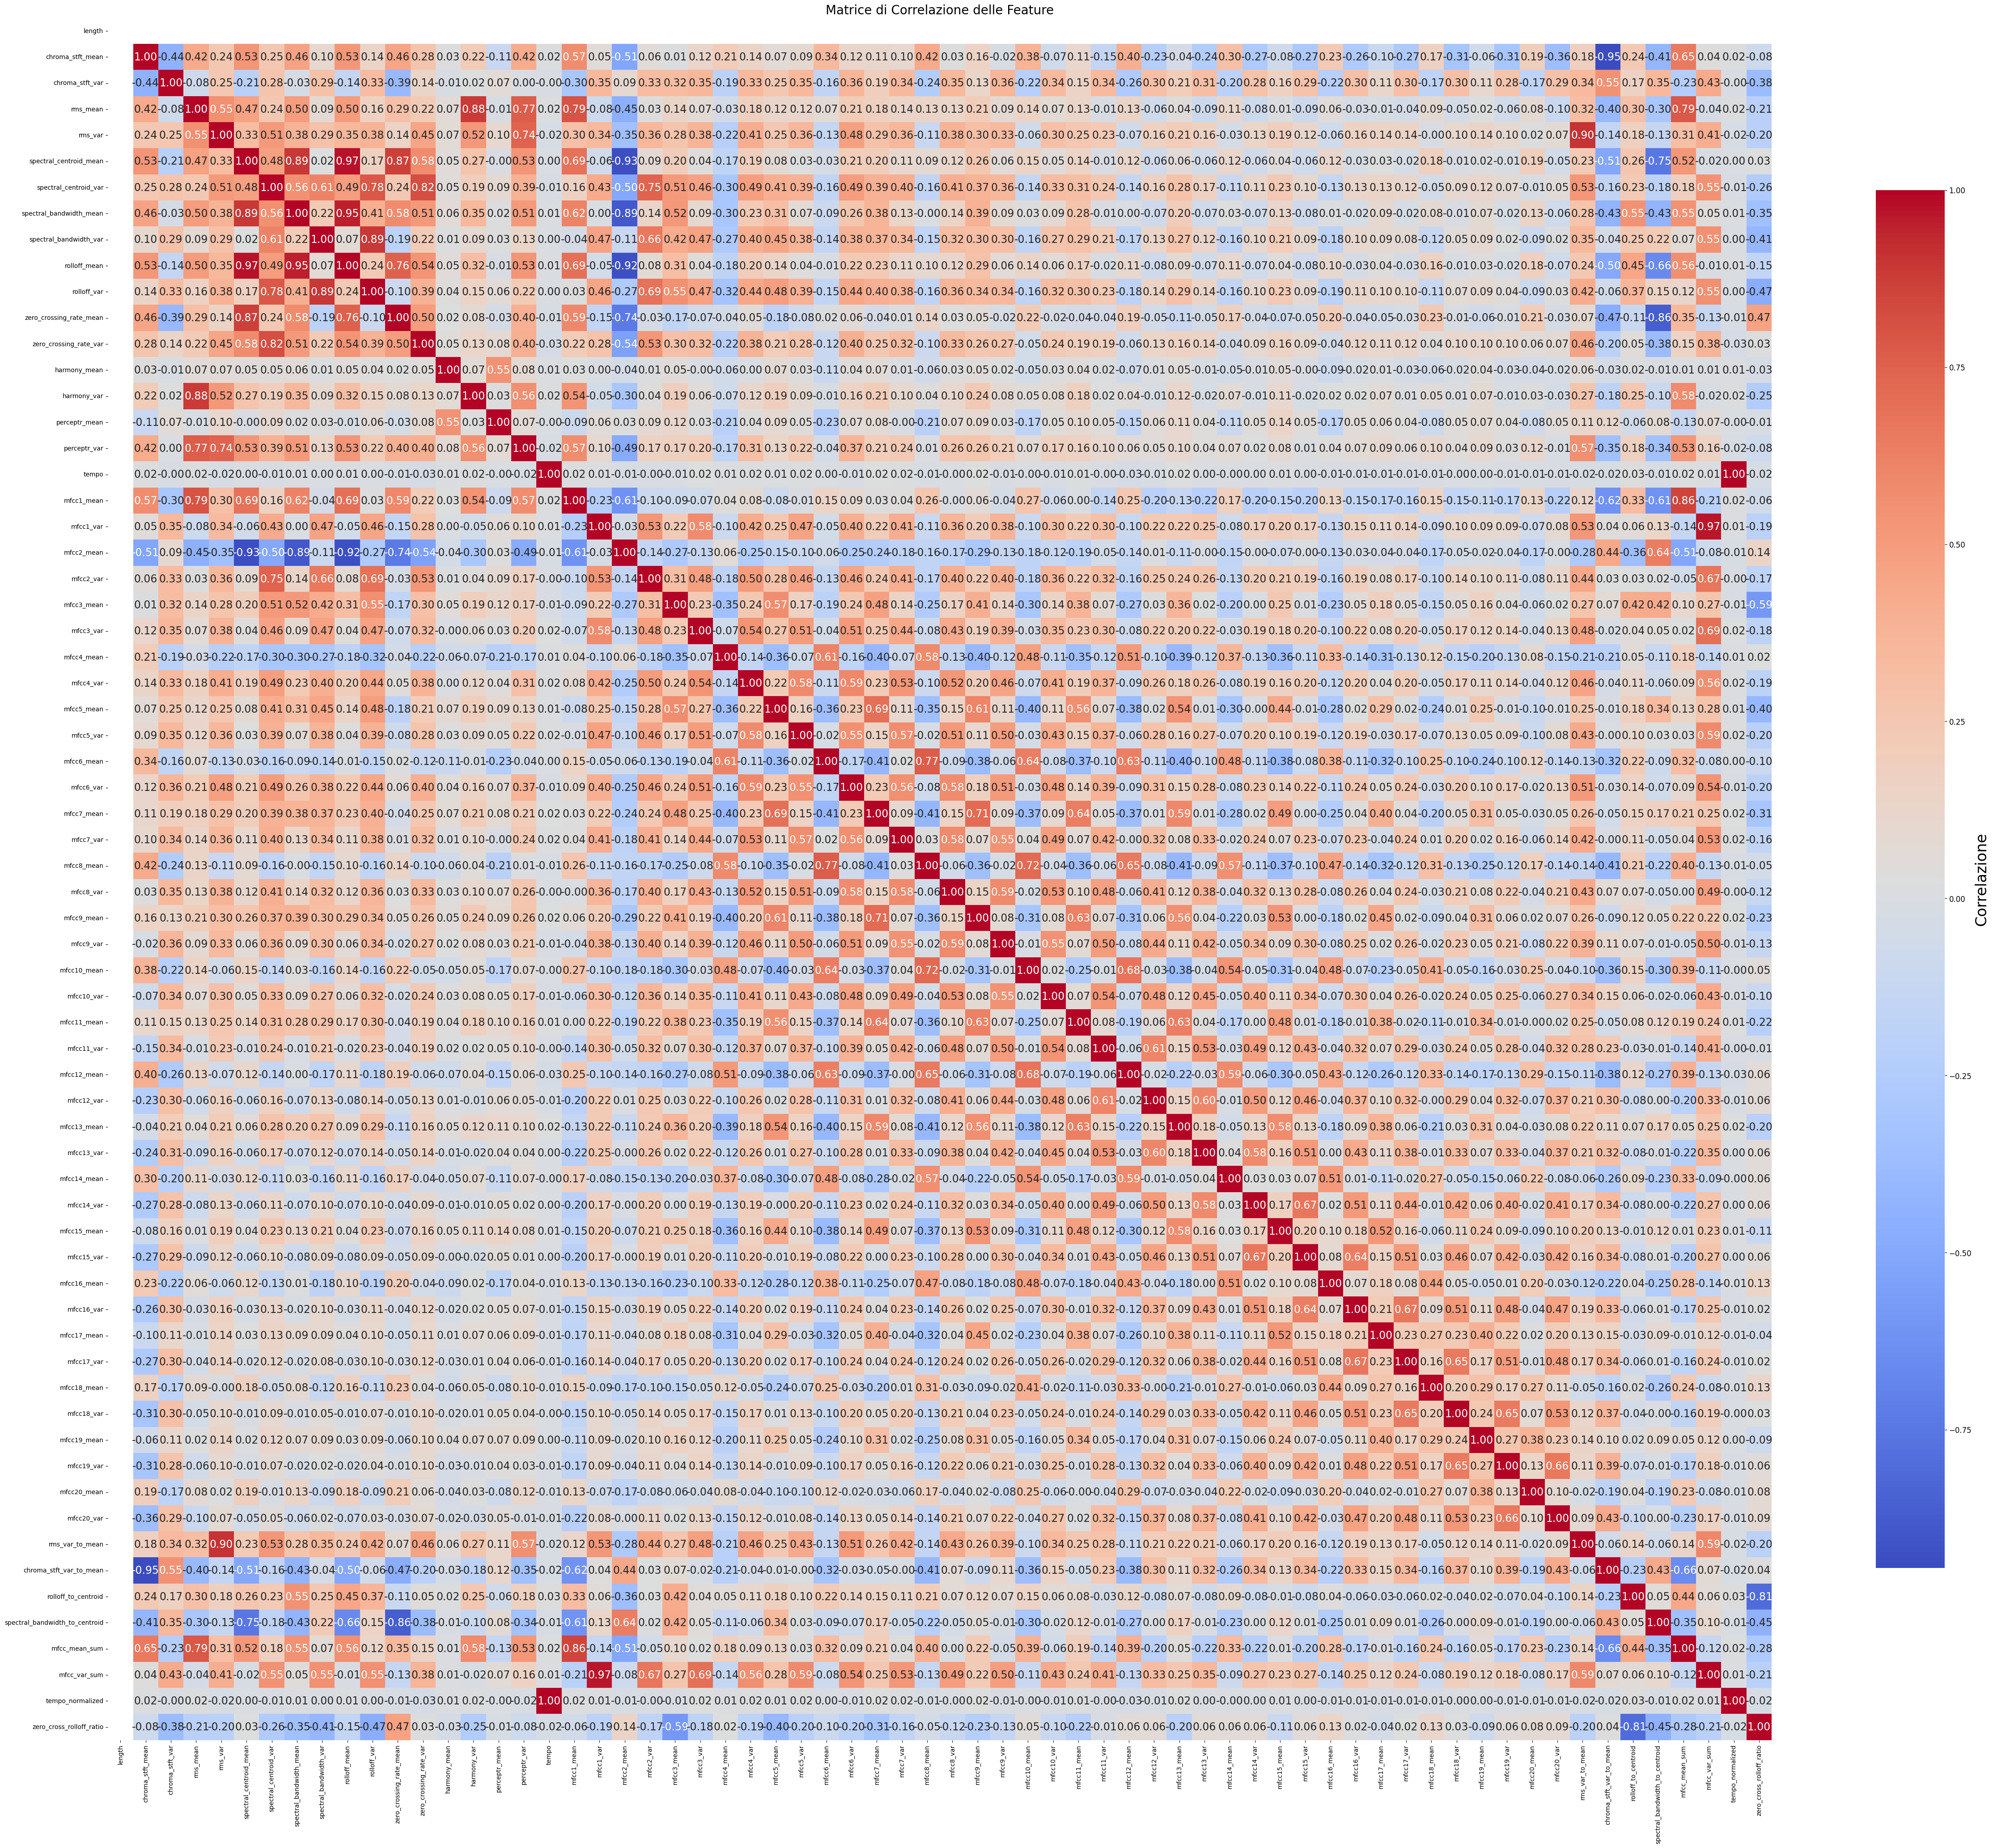

In [14]:
# Rimuovi le colonne non numeriche

X = music_data_mod.drop(columns=['label', 'filename'])

# Calcola la matrice di correlazione
correlation_matrix = X.corr()

# Configura la dimensione della heatmap
plt.figure(figsize=(60, 50))

# Crea la heatmap
heatmap = sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm',
                       xticklabels=X.columns, yticklabels=X.columns,
                       annot_kws={"size": 17},  # Aumenta la dimensione del font per i valori
                       cbar_kws={"shrink": 0.8, "label": "Correlazione"})  # Rimuovi fontsize da qui


plt.title('Matrice di Correlazione delle Feature', fontsize=20)  # Aumenta la dimensione del titolo


# Personalizza il colorbar
colorbar = heatmap.collections[0].colorbar  # Ottieni il colorbar dalla heatmap
colorbar.ax.tick_params(labelsize=12)  # Aumenta la dimensione del font dei ticks
colorbar.set_label("Correlazione", fontsize=24)  # Imposta il font della label del colorbar


# Mostra la heatmap

plt.show()